In [59]:
#Code borrowed from EOG Lab (lab 2)

#core libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import re
import warnings
warnings.filterwarnings('ignore')
#I don't know if some of these are needed but I am not removing them as to not break things.

#processing libs
from scipy import signal
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

#for real-time plotting
import plotly.graph_objects as go

#Plotting settings from lab 2 that I'm not touching to not break things
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")

All libraries imported successfully!


In [61]:
#Data path
DATA_DIR = Path("/Users/jonathanpelletier/Documents/BioRobotics-Lab2-main/recordings/Horizontal/custom/TestDataSet.csv")  # Adjust this to your data location

#Recording params
SAMPLE_RATE = 250  # Hz (should match your BioRadio configuration)

#Channel mapping
HEOG_CHANNEL = 0  # Horizontal EOG (Channel 1 on BioRadio)
VEOG_CHANNEL = 1  # Vertical EOG (Channel 2 on BioRadio)

#Calibration params
#[Overall Width, Overall Height, Distance]
#All in inches since I only had an imperial measuring tape when I was doing data collection
#Reach goal: metric conversion parameters
DISTS = [144,46,72]

#Filter params
LOWPASS_CUTOFF = 30  # Hz - EOG content is below 30 Hz
HIGHPASS_CUTOFF = 0.1  # Hz - removes very slow drift (optional)

print(f"Data directory: {DATA_DIR.absolute()}")
print(f"Sample rate: {SAMPLE_RATE} Hz")
print(f"Gaze classes: {DISTS}")

Data directory: /Users/jonathanpelletier/Documents/BioRobotics-Lab2-main/recordings/Horizontal/custom/TestDataSet.csv
Sample rate: 250 Hz
Gaze classes: [144, 46, 72]


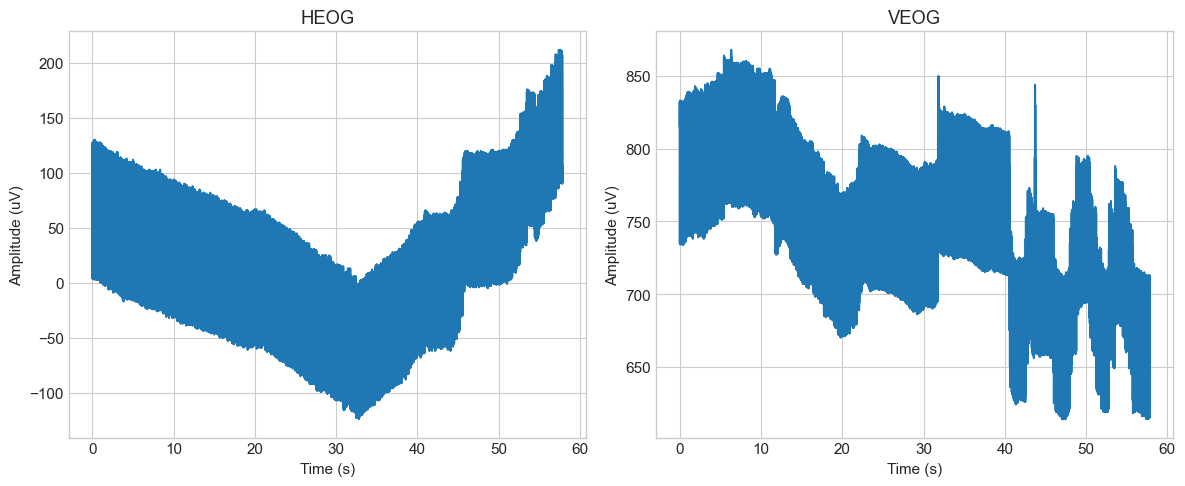

In [64]:
#Load file
df = pd.read_csv(DATA_DIR)

#Extract arrays
df.columns = df.columns.str.strip().str.lower()
df['heog'] = df['ch0']
df['veog'] = df['ch1']

#Time axis
time = np.arange(len(df)) / SAMPLE_RATE

#Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(time, df['heog'])
plt.title("HEOG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")

plt.subplot(1, 2, 2)
plt.plot(time, df['veog'])
plt.title("VEOG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")

plt.tight_layout()
plt.show()


In [68]:
def baseline_correction(signal_data, method='mean'):
    return signal_data - np.mean(signal_data)

def lowpass_filter(signal_data, cutoff=LOWPASS_CUTOFF, sample_rate=SAMPLE_RATE, order=4):
    nyquist = sample_rate / 2
    normalized_cutoff = cutoff / nyquist
    
    b, a = signal.butter(order, normalized_cutoff, btype='low')
    
    # Use filtfilt for zero-phase filtering
    return signal.filtfilt(b, a, signal_data)


def bandpass_filter(signal_data, low_cutoff=HIGHPASS_CUTOFF, high_cutoff=LOWPASS_CUTOFF,
                    sample_rate=SAMPLE_RATE, order=4):
    nyquist = sample_rate / 2
    low = low_cutoff / nyquist
    high = high_cutoff / nyquist
    
    b, a = signal.butter(order, [low, high], btype='band')
    
    return signal.filtfilt(b, a, signal_data)


def process_eog_signal(signal_data, sample_rate=SAMPLE_RATE,
                       remove_baseline=True, remove_slow_drift=False,
                       apply_lowpass=True, lowpass_cutoff=LOWPASS_CUTOFF):

    processed = signal_data.copy()
    
    if remove_baseline:
        processed = baseline_correction(processed, method='mean')
    
    if apply_lowpass:
        processed = lowpass_filter(processed, cutoff=lowpass_cutoff,
                                   sample_rate=sample_rate)
    #My own code, has to smooth my data and found this in the documentation and it works well
    processed = uniform_filter1d(processed, size=15)
    
    return processed

print("Signal processing functions defined!")

Signal processing functions defined!


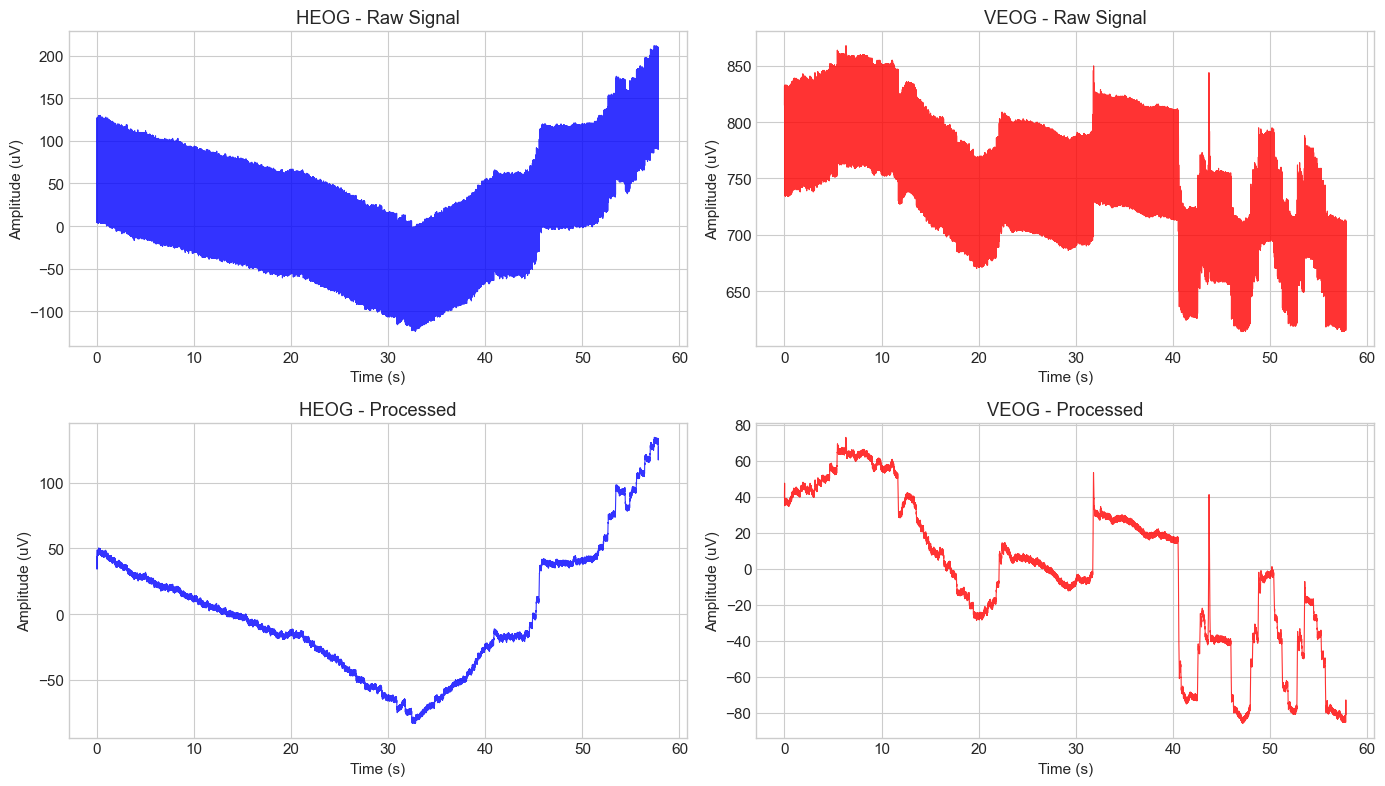

In [71]:
def plot_processing_comparison(trial_data, sample_rate=SAMPLE_RATE):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    time = np.arange(len(trial_data)) / sample_rate
    
    channels = [('heog', 'HEOG', 'blue'), ('veog', 'VEOG', 'red')]
    
    for col, (ch_name, ch_label, color) in enumerate(channels):
        if ch_name not in trial_data.columns:
            continue
            
        raw = trial_data[ch_name].values
        processed = process_eog_signal(raw, sample_rate=sample_rate)
        
        #unfiltered signal
        axes[0, col].plot(time, raw, color=color, linewidth=0.8, alpha=0.8)
        axes[0, col].set_title(f'{ch_label} - Raw Signal')
        axes[0, col].set_xlabel('Time (s)')
        axes[0, col].set_ylabel('Amplitude (uV)')
        
        #processed signal
        axes[1, col].plot(time, processed, color=color, linewidth=0.8, alpha=0.8)
        axes[1, col].set_title(f'{ch_label} - Processed')
        axes[1, col].set_xlabel('Time (s)')
        axes[1, col].set_ylabel('Amplitude (uV)')
    
    plt.tight_layout()
    plt.show()

plot_processing_comparison(df)


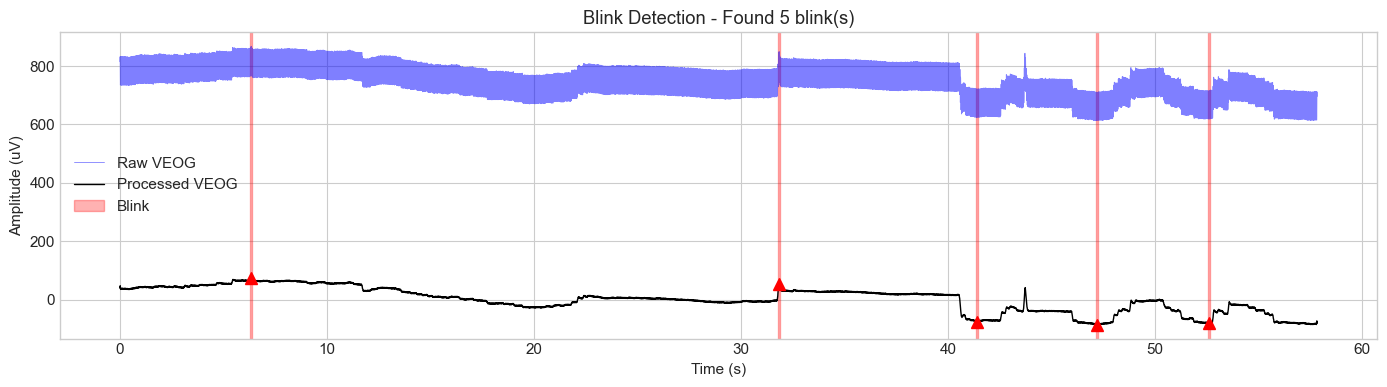

Detected 5 blinks


In [75]:
def detect_blinks(veog_signal, sample_rate=SAMPLE_RATE,prominence_factor=0.8,min_distance_ms=200):
    processed = process_eog_signal(veog_signal, sample_rate=sample_rate)
    std = np.std(processed)
    prominence = prominence_factor * std
    min_distance = int(min_distance_ms * sample_rate / 1000)
    peaks, properties = find_peaks(np.abs(processed),prominence=prominence,distance=min_distance)
    blinks = []
    for peak in peaks:
        #estimate blink time around peaks
        start = max(0, peak - int(0.05 * sample_rate))
        end = min(len(processed), peak + int(0.05 * sample_rate))
        blinks.append((start, end, peak))

    return blinks, processed

#AI help here for plotting the blinks, but not for detecting them
def plot_blink_detection(df, sample_rate=SAMPLE_RATE):
    veog = df['veog'].values
    time = np.arange(len(veog)) / sample_rate

    blinks, processed = detect_blinks(veog, sample_rate=sample_rate)

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(time, veog, 'b-', linewidth=0.6, alpha=0.5, label='Raw VEOG')
    ax.plot(time, processed, 'k-', linewidth=1.0, label='Processed VEOG')

    first = True
    for start, end, peak in blinks:
        ax.axvspan(start/sample_rate, end/sample_rate,
                   color='red', alpha=0.3,
                   label='Blink' if first else "")
        ax.plot(peak/sample_rate, processed[peak], 'r^', markersize=8)
        first = False

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (uV)')
    ax.set_title(f'Blink Detection - Found {len(blinks)} blink(s)')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return blinks

detected = plot_blink_detection(df)

print(f"Detected {len(detected)} blinks")

In [77]:
def extract_features(df, sample_rate=SAMPLE_RATE):
    features = {}

    for ch_name in ['heog', 'veog']:
        if ch_name not in df.columns:
            continue

        raw = df[ch_name].values
        processed = process_eog_signal(raw, sample_rate=sample_rate)

        prefix = ch_name.upper()

        #Used AI to help get the data frame right here for printing and displaying
        features[f'{prefix}_min'] = np.min(processed)
        features[f'{prefix}_max'] = np.max(processed)
        features[f'{prefix}_ptp'] = np.ptp(processed)

    return features
    
features = extract_features(df)

#cast to data frame to print nicely
feature_df = pd.DataFrame([features])

print(feature_df)

    HEOG_min    HEOG_max    HEOG_ptp   VEOG_min   VEOG_max    VEOG_ptp
0 -83.226517  134.553962  217.780478 -85.741853  72.887315  158.629168


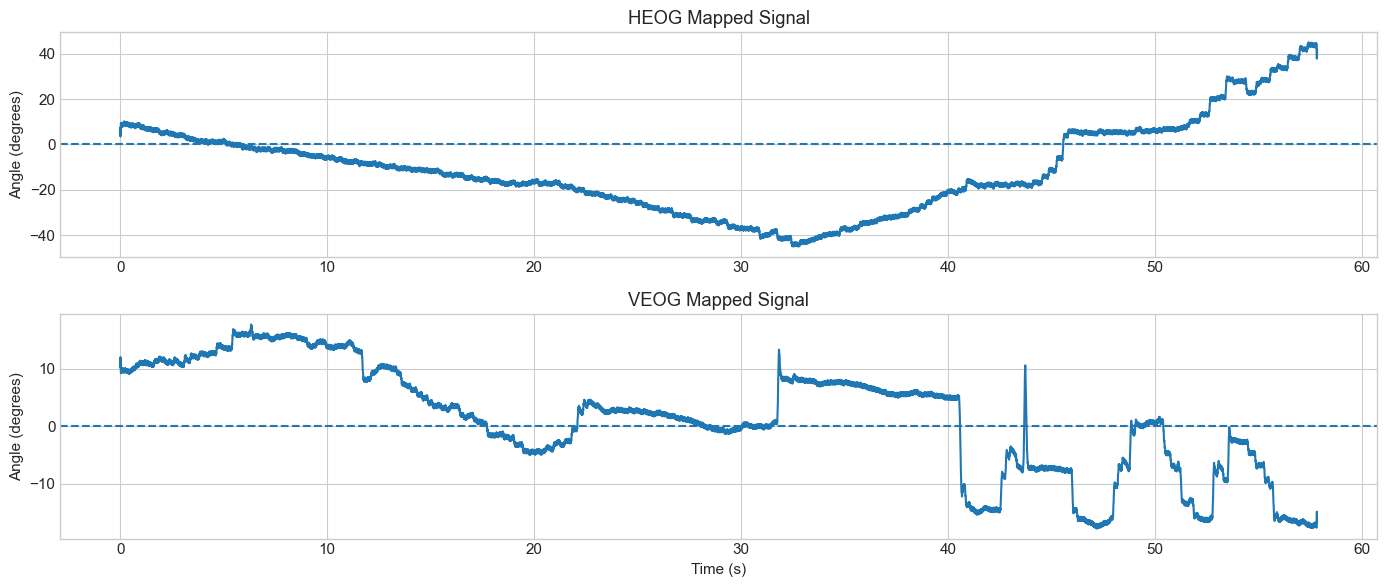

In [81]:
MidH = DISTS[0]/2
MidV = DISTS[1]/2
MidH_v = (features['HEOG_max'] + features['HEOG_min'])/2
MidV_v = (features['VEOG_max'] + features['VEOG_min'])/2
#print(MidH_v)
#print(MidV_v)
#computing calibrations and using casting since numpy functions work in radians 
H_FOVp = np.degrees(np.arctan(MidH/DISTS[2]))
H_FOVn = -np.degrees(np.arctan(MidH/DISTS[2]))
#print(H_FOVn)
V_FOVp = np.degrees(np.arctan(MidV/DISTS[2]))
V_FOVn = -np.degrees(np.arctan(MidV/DISTS[2]))
#print(V_FOVn)
for ch_name in ['heog', 'veog']:
    raw = df[ch_name].values
    processed = process_eog_signal(raw, sample_rate=SAMPLE_RATE)
    #AI fix for data not showing up right in the graphs
    if ch_name == 'heog':
        heog = processed
    elif ch_name == 'veog':
        veog = processed

def map_signal_to_arbitrary(signal, min_val, max_val):
    min_val = np.min(signal)
    max_val = np.max(signal)
    midpoint = (max_val + min_val) / 2
    half_range = (max_val - min_val) / 2
    #fixes a divide-by-zero error
    if half_range == 0:
        return np.zeros_like(signal)

    mapped = (signal - midpoint) / half_range
    #"clips" to the set bounds
    return np.clip(mapped, min_val, max_val)

#goes from [-1,1] to the overall degree values
h_mapped_values = H_FOVp*map_signal_to_arbitrary(heog, H_FOVn, H_FOVp)
v_mapped_values = V_FOVp*map_signal_to_arbitrary(veog, V_FOVn, V_FOVp)

def plot_mapped_signals(h_values, v_values, sample_rate=SAMPLE_RATE):
    time = np.arange(len(h_values)) / sample_rate

    plt.figure(figsize=(14, 6))

    #heog
    plt.subplot(2, 1, 1)
    plt.plot(time, h_values)
    plt.axhline(0, linestyle='--')
    plt.title('HEOG Mapped Signal')
    plt.ylabel('Angle (degrees)')

    #veog
    plt.subplot(2, 1, 2)
    plt.plot(time, v_values)
    plt.axhline(0, linestyle='--')
    plt.title('VEOG Mapped Signal')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (degrees)')

    plt.tight_layout()
    plt.show()

plot_mapped_signals(h_mapped_values, v_mapped_values)

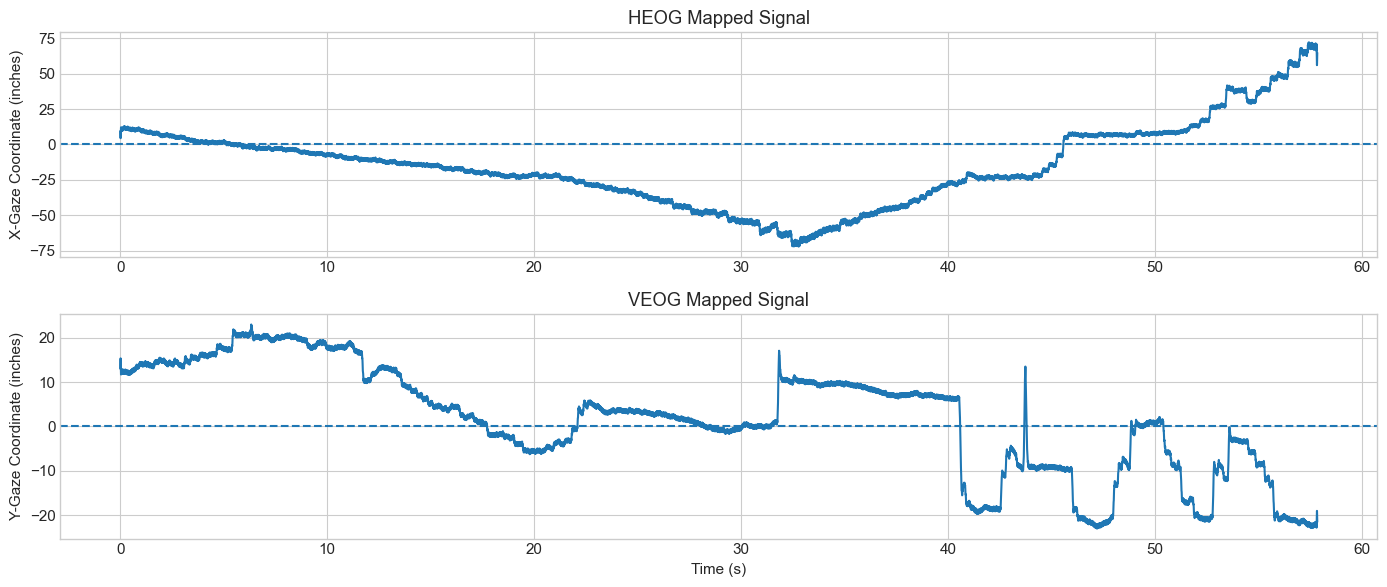

In [82]:
x_vals = DISTS[2] * np.tan(np.deg2rad(h_mapped_values))
y_vals = DISTS[2] * np.tan(np.deg2rad(v_mapped_values))
def plot_mapped_signals(h_values, v_values, sample_rate=SAMPLE_RATE):
    time = np.arange(len(h_values)) / sample_rate

    plt.figure(figsize=(14, 6))
    #heog
    plt.subplot(2, 1, 1)
    plt.plot(time, h_values)
    plt.axhline(0, linestyle='--')
    plt.title('HEOG Mapped Signal')
    plt.ylabel('X-Gaze Coordinate (inches)')

    #veog
    plt.subplot(2, 1, 2)
    plt.plot(time, v_values)
    plt.axhline(0, linestyle='--')
    plt.title('VEOG Mapped Signal')
    plt.xlabel('Time (s)')
    plt.ylabel('Y-Gaze Coordinate (inches)')

    plt.tight_layout()
    plt.show()

plot_mapped_signals(x_vals, y_vals)

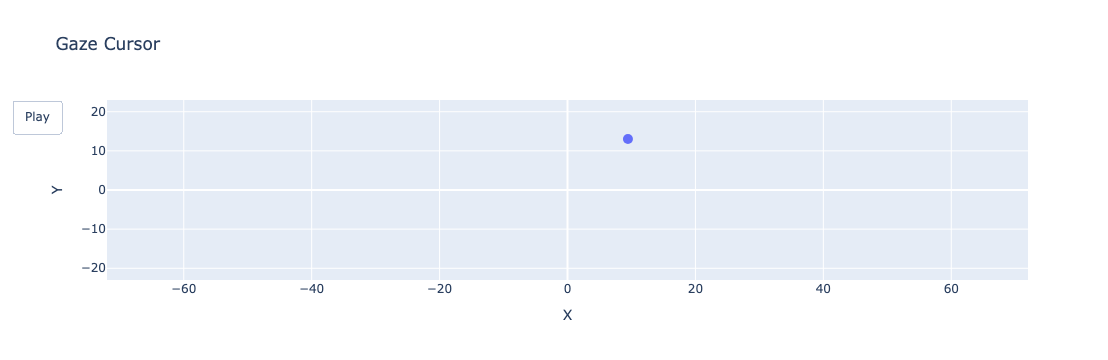

In [83]:
def animate_gaze_plotly(x_vals, y_vals, step):
    #AI used to help with this function since I've never used plotly library
    #downsampling
    x_vals = x_vals[::step]
    y_vals = y_vals[::step]

    #figure creation
    fig = go.Figure(
        data=[
            go.Scatter(
                x=[x_vals[0]],
                y=[y_vals[0]],
                mode="markers",
                marker=dict(size=10),
                name="Cursor"
            ),
            go.Scatter(
                x=[],
                y=[],
                mode="lines",
                line=dict(width=2),
                name="Trail"
            )
        ],
        layout=go.Layout(
            title="Gaze Cursor",
            xaxis=dict(range=[-72, 72], title="X"),
            yaxis=dict(range=[-23, 23], title="Y"),
            updatemenus=[dict(
                type="buttons",
                showactive=False,
                buttons=[dict(label="Play",
                              method="animate",
                              args=[None])]
            )]
        ),
        frames=[
            go.Frame(
                data=[
                    go.Scatter(x=[x_vals[i]], y=[y_vals[i]]),
                    go.Scatter(x=x_vals[:i+1], y=y_vals[:i+1])
                ]
            )
            for i in range(len(x_vals))
        ]
    )

    fig.show()

animate_gaze_plotly(x_vals, y_vals, 300)

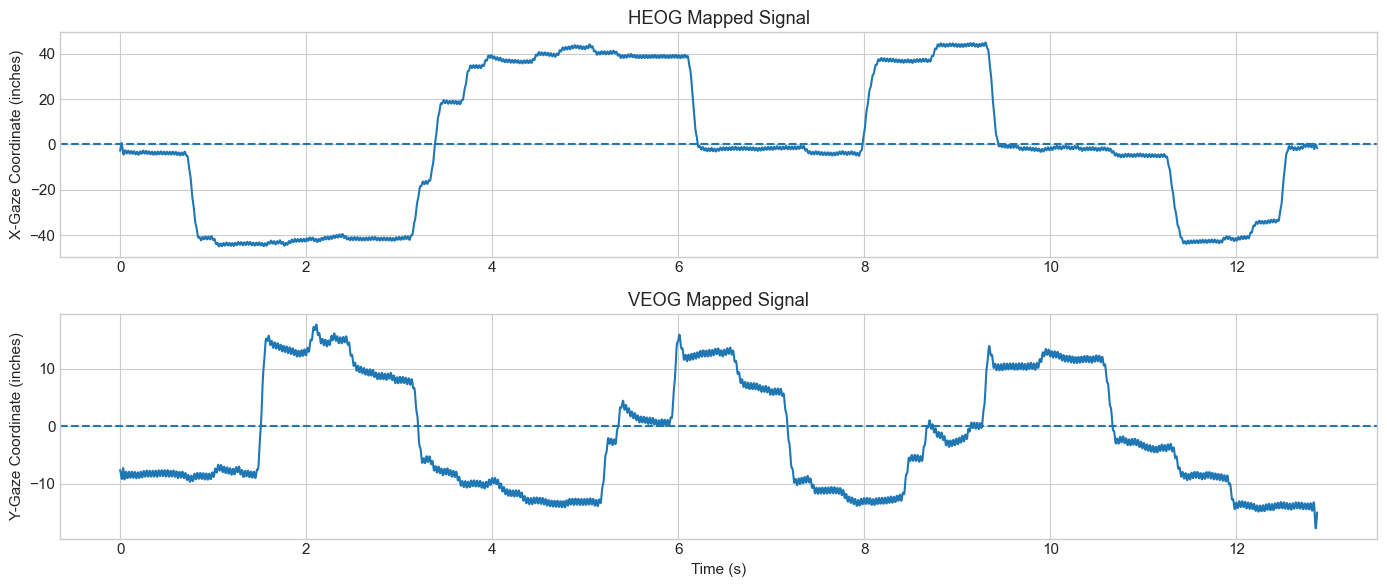

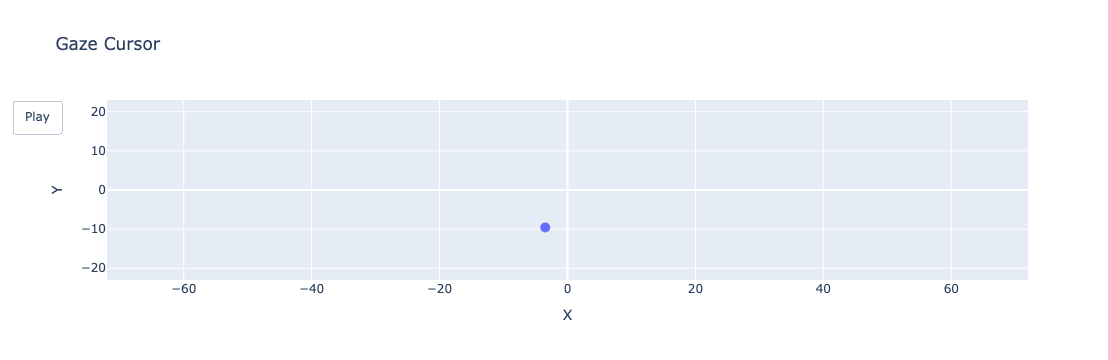

In [84]:
#load the free look data
DATA_DIR_2 = Path("/Users/jonathanpelletier/Documents/BioRobotics-Lab2-main/recordings/Horizontal_FL/custom/FreeLookData.csv")
df2 = pd.read_csv(DATA_DIR_2)

#data pipeline
df2.columns = df2.columns.str.strip().str.lower()
df2['heog'] = df2['ch0']
df2['veog'] = df2['ch1']

heog2 = process_eog_signal(df2['heog'].values, sample_rate=SAMPLE_RATE)
veog2 = process_eog_signal(df2['veog'].values, sample_rate=SAMPLE_RATE)

features2 = extract_features(df2)
feature_df = pd.DataFrame([features])
MidH_v2 = (features['HEOG_max'] + features['HEOG_min'])/2
MidV_v2 = (features['VEOG_max'] + features['VEOG_min'])/2
#print(MidH_v)
#print(MidV_v)
H_FOVp2 = np.degrees(np.arctan(MidH/DISTS[2]))
H_FOVn2 = -np.degrees(np.arctan(MidH/DISTS[2]))
#print(H_FOVn2)
V_FOVp2 = np.degrees(np.arctan(MidV/DISTS[2]))
V_FOVn2 = -np.degrees(np.arctan(MidV/DISTS[2]))

h_mapped_values2 = H_FOVp2*map_signal_to_arbitrary(heog2, H_FOVn2, H_FOVp2)
v_mapped_values2 = V_FOVp2*map_signal_to_arbitrary(veog2, V_FOVn2, V_FOVp2)

x_vals2 = DISTS[2] * np.tan(np.deg2rad(h_mapped_values2))
y_vals2 = DISTS[2] * np.tan(np.deg2rad(v_mapped_values2))

plot_mapped_signals(h_mapped_values2, v_mapped_values2)
animate_gaze_plotly(x_vals2, y_vals2,100)

In [44]:
#This portion of code is adapted from homework 5

In [87]:
'''Class Prototype for Layers'''
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    # computes the output Y of a layer for a given input X
    def forward_propagation(self, input_data):
        raise NotImplementedError

    # computes dE/dX for a given dE/dY (and update parameters if any)
    def backward_propagation(self, output_error, learning_rate):
        raise NotImplementedError
        
'''Loss Functions and its derivative'''
def mse(y_true, y_pred):
    return np.mean(np.power(y_true-y_pred, 2));

def mse_prime(y_true, y_pred):
    return 2*(y_pred-y_true)/y_true.size;

'''Activation function and its derivative'''
def tanh(x):
    return np.tanh(x);

def tanh_prime(x):
    return 1-np.tanh(x)**2;

'''Please run this each time, to ensure we have the correct random seed'''
np.random.seed(2)


In [88]:
# inherit from base class Layer
class FCLayer(Layer):
    
    # input_size = number of input neurons
    # output_size = number of output neurons
    def __init__(self, input_size, output_size):
        self.weights = np.random.rand(input_size, output_size) 
        self.bias = np.random.rand(1, output_size)
        self.input = None
        self.output = None
    
    # computes the output Y of a layer for a given input X
    def forward_propagation(self, input_data):
        '''Your turn to calculate input and output of a layer'''
        #weights  = 2x1
        #bias = 1x1
        #input = 1x2
        self.input  = input_data
        self.output =input_data@self.weights + self.bias
        #gave me a 2x2 instead of 1x1 with * so I looked up that kind of error and apparently @ fixes it
        #np.dot() also gives a 2x2 for me 
        
        return self.output

    # computes dE/dX for a given dE/dY (and update parameters if any)
    def backward_propagation(self, output_error, learning_rate):
        
        '''Calculate input and weights error'''
        input_error   = output_error @ np.transpose(self.weights)
        weights_error = np.transpose(self.input) @ output_error
        
        '''Update Parameters'''
        self.weights = self.weights - learning_rate*weights_error
        self.bias    = self.bias - learning_rate*output_error
        
        '''Return Something'''
        return input_error
    


In [89]:
'''Testing the FC layer'''

'''Input and True Output'''
x = np.array([[0, 1]])
lr = 0.01
y = np.array([1])

fclayer = FCLayer(2, 1)

np.random.seed(2)

'''Testing Forward Propogation'''
display("Forward prop:", fclayer.forward_propagation(x))
assert np.allclose(fclayer.forward_propagation(x),np.array([[0.57558871]]))


'''Calculating Error'''
error = (y - fclayer.output)**2

display("error:",error)
assert np.allclose(error,np.array([[0.18012494]]))

output_error = 2*(fclayer.output - y)
print(output_error)


'''Testing Backward Propagation de/dx'''
input_error = fclayer.backward_propagation(output_error, lr)

display("input_error:", input_error)

assert np.allclose(input_error, np.array([[-0.37008232, -0.02200677]]))

'''Testing new weights and bias'''
display("Weights and Bias:",fclayer.weights, fclayer.bias)

assert np.allclose(fclayer.weights, np.array([[0.4359949 ], [0.03441446]]))

assert np.allclose(fclayer.bias, np.array([[0.5581507]]))

'Forward prop:'

array([[0.57558871]])

'error:'

array([[0.18012494]])

[[-0.84882258]]


'input_error:'

array([[-0.37008232, -0.02200677]])

'Weights and Bias:'

array([[0.4359949 ],
       [0.03441446]])

array([[0.5581507]])

In [90]:
# inherit from base class Layer
class ActivationLayer(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    # returns the activated input
    def forward_propagation(self, input_data):
        self.input  = input_data
        self.output = self.activation(self.input)
        return self.output

    # Returns input_error=dE/dX for a given output_error=dE/dY.
    # learning_rate is not used because there is no "learnable" parameters.
    def backward_propagation(self, output_error, learning_rate):
        ''' Your code here'''
        input_error = output_error * self.activation_prime(self.input)
        
        return input_error
    

In [91]:
'''Testing your code'''
x = np.array([[100]])
lr = 0.01
y = np.array([1])

actLayer = ActivationLayer(tanh, tanh_prime)

display('forward prop')
display(actLayer.forward_propagation(x))

error = (y - actLayer.output)**2

display('error')
display(error)

display('back prop')
display(actLayer.backward_propagation(2*(actLayer.output - y), lr))

'''
Notice that I did not do any all close here. Its your job to think about 
what the results should be and if your code is correct.
'''
#Results look off but are technically numerically correct so Im gonna roll with it

'forward prop'

array([[1.]])

'error'

array([[0.]])

'back prop'

array([[0.]])

'\nNotice that I did not do any all close here. Its your job to think about \nwhat the results should be and if your code is correct.\n'

In [92]:
class Network:
    ''' Network class, where layers are added sequentially using the .add method'''
    def __init__(self, loss = None, loss_prime =None):
        '''your code here'''
        self.layers = []
        self.history = []

    # add a single layer to the network
    def add(self, layer):
        '''Your code here'''
        self.layers.append(layer)

    # set loss to use
    def set_loss(self, loss, loss_prime):
        self.loss = loss
        self.loss_prime = loss_prime

    # predict output for given input
    def predict(self, input_data):
        result = []
        
        ''' Your code here'''
        #seems redundant but is a bug fix for a size mismatch error
        for x in input_data:
            output = x
            for l in self.layers:
                output = l.forward_propagation(output)

        result.append(output)
       

        return result

    # train the network
    def fit(self, x_train, y_train, epochs, learning_rate): 

        '''Your code here'''
        for e in range(epochs):
            error = 0
            #for x in x_train:
                #for y in y_train:
            for x, y in zip(x_train, y_train):
            #was giving a lot of error (error > 1) so I looked up the documentation of zip() to do both x and y at once

                #forward prop
                output = x
                for l in self.layers:
                    output = l.forward_propagation(output)
                #loss    
                error = error + self.loss(y, output)
                #backprop
                gradient = self.loss_prime(y, output)
                #use reversed() since I wanna go through backwards
                for l in reversed(self.layers):
                    gradient = l.backward_propagation(gradient, learning_rate)

            #avg error
            error = error / len(x_train)
            self.history.append(error)

        display('epoch')
        display(e+1)
        display('error')
        display(error)
        
        return self.history

In [93]:
# Reset seed
np.random.seed(2)

# XOR training data
x_train = np.column_stack((df['heog'].values, df['veog'].values))
x_train = (x_train - np.mean(x_train, axis=0)) / np.std(x_train, axis=0)
x_train = x_train.reshape(-1, 1, 2)

y_train = np.column_stack((x_vals, y_vals))
y_train = y_train / np.max(np.abs(y_train), axis=0)
y_train = y_train.reshape(-1, 1, 2)

x_test = np.column_stack((df2['heog'].values, df2['veog'].values))
x_test = (x_test - np.mean(x_test, axis=0)) / np.std(x_test, axis=0)
x_test = x_test.reshape(-1, 1, 2)

y_test = np.column_stack((x_vals2, y_vals2))
y_test = y_test / np.max(np.abs(y_train), axis=0)  # use TRAIN scaling
y_test = y_test.reshape(-1, 1, 2)

#network creation    
net = Network()
#add layers
net.add(FCLayer(2, 3))
net.add(ActivationLayer(tanh, tanh_prime))
net.add(FCLayer(3, 2))
net.add(ActivationLayer(tanh, tanh_prime))
#loss func
net.set_loss(mse, mse_prime)
#before training
#display('before training')
#for x in x_train:
    #output = net.predict(x)
    #display(output)

#train
history = net.fit(x_train, y_train, epochs=800, learning_rate=0.1)

#after training
#display('after training')
#for x in x_train:
    #output = net.predict(x)
    #display(output)

'epoch'

800

'error'

np.float64(0.000781418263190827)

In [95]:
#Above cell takes some time to train since there is a LOT of data and calcs to run

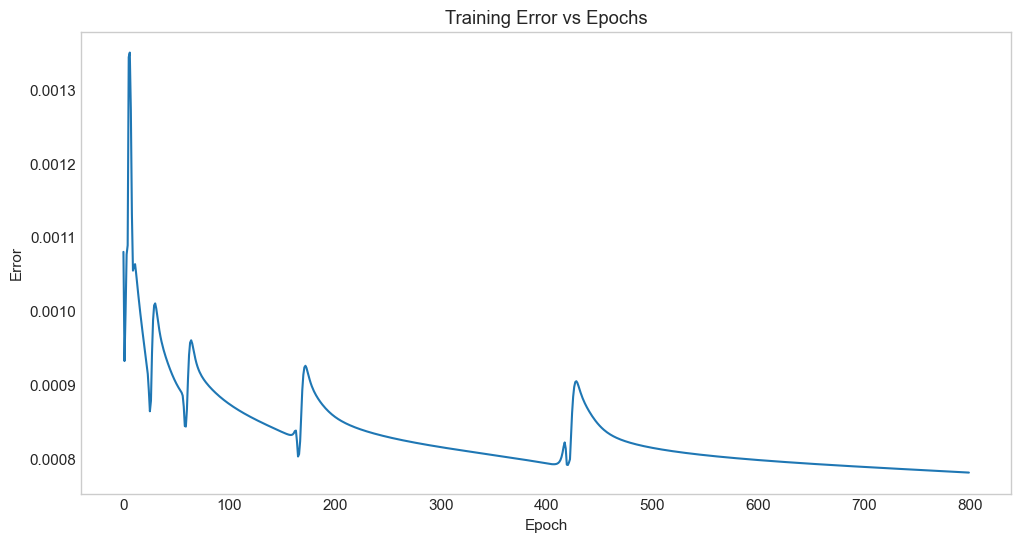

In [96]:
import matplotlib.pyplot as plt
'''Your code here'''
plt.plot(history)
plt.title("Training Error vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.grid()
plt.show()